In [1]:
# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning
    
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import boto3
from sklearn.linear_model import LogisticRegression

(CVXPY) Feb 20 05:40:35 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Feb 20 05:40:35 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def bin_features(list_cols, X, y, dict_monotone_constraints):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
            
        # logic
        if col == 'ENG-wtd_avg':
            prebinning_method = 'uniform'
        else:
            prebinning_method = 'cart'
        
        # check under 0.5 -- comment out
        user_splits = [0.5]
        
        # init
        cls_binning = OptimalBinning(
            name=col,
            dtype='numerical',
            solver='cp',
            monotonic_trend=str_monotonic_trend,
            prebinning_method=prebinning_method,
            user_splits=None,
            user_splits_fixed=None,
        )
        # fit
        cls_binning.fit(
            X[col],
            y,
        )
        # assign
        dict_bins[col] = cls_binning
        # transform
        str_col = f'{col}_binned'
        X[str_col] = cls_binning.transform(
            X[col],
            metric='woe',
        )
        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X

#### Constants

In [3]:
str_uri_bin = 's3://20241112-simple-model-test/09_60_in_720/01_data_split'

str_target = 'Early_Pay_Delinquency_60_720_Flag'

list_cols = [
    'g232s__tu',
    'ENG-wtd_avg',
#     'ENG-bk',
            ]

# dict monotone constraints
dict_monotone_constraints = {'g232s__tu':1,
                            'ENG-wtd_avg':-1}

#### Output directory

In [4]:
try:
    os.mkdir('./output')
except:
    pass

#### load in data to check bins

In [5]:
# load in train val test
df_train = pd.read_parquet(f'{str_uri_bin}/df_train.gzip')
df_test = pd.read_parquet(f'{str_uri_bin}/df_test.gzip')
df_holdout = pd.read_parquet(f'{str_uri_bin}/df_holdout.gzip')

# concat
df = pd.concat([df_train, df_test, df_holdout])

# del to save memory
del df_train, df_test, df_holdout

# subset to only the stuff we want
# list_cols.append(str_target)
df_tmp = df[list_cols]

# fill na 0 for wtd avg
df_tmp['ENG-wtd_avg'] = df_tmp['ENG-wtd_avg'].fillna(0)

# fill na with max for g232s__tu fill with 383
df_tmp['g232s__tu'] = df_tmp['g232s__tu'].fillna(383)

# show
df_tmp

/tmp/ipykernel_14365/3851123018.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['ENG-wtd_avg'] = df_tmp['ENG-wtd_avg'].fillna(0)
/tmp/ipykernel_14365/3851123018.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['g232s__tu'] = df_tmp['g232s__tu'].fillna(383)


,g232s__tu,ENG-wtd_avg
0,43.0,0.616667
1,3.0,0.000000
2,13.0,0.000000
3,31.0,1.000000
4,1.0,1.000000
...,...,...
41693,31.0,0.133005
41694,30.0,0.384615
41695,10.0,0.000000
41696,7.0,0.137374


#### Get bins

In [6]:
dict_bins, list_cols_scorecard, X = bin_features(
    list_cols=list_cols,
    X=df_tmp,
    y=df[str_target],
    dict_monotone_constraints=dict_monotone_constraints,
)
# pickle dict_bins
str_filename = 'dict_bins.pkl'
str_local_path = f'./output/{str_filename}'
pickle.dump(dict_bins, open(str_local_path, 'wb'))

  0%|          | 0/2 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/

/tmp/ipykernel_14365/3158443612.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[str_col] = cls_binning.transform(
100%|██████████| 2/2 [00:00<00:00, 10.30it/s]


In [7]:
# import
str_filename = './output/dict_bins.pkl'
str_local_path = f'{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# transform
for key, val in tqdm(dict_bins.items()):
    try:
        df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])
    except KeyError:
        pass

  0%|          | 0/2 [00:00<?, ?it/s]/tmp/ipykernel_14365/2286728030.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])
100%|██████████| 2/2 [00:00<00:00, 337.94it/s]


In [8]:
# get binned named
list_cols_binned = [col for col in list(df_tmp.columns) if 'binned' in col]

# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_binned):
    int_n_unique = df_tmp[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
for a, col in enumerate(list_col_no_var):
    print(f'{a+1} - {col}')
# rm
list_cols_binned = [col for col in list_cols_binned if col not in list_col_no_var]
print(f'There are {len(list_cols_binned)} features with good variance')

100%|██████████| 2/2 [00:00<00:00, 1445.07it/s]

There are 0 features with no variance after binning
There are 2 features with good variance


### Fit a simple Logistic Regression to get the coeff

In [9]:
cls_model_inference = LogisticRegression(
    fit_intercept=True
)

cls_model_inference.fit(
    df_tmp[['g232s__tu_binned']],
    df[str_target],
)

flt_coef = cls_model_inference.coef_[0][0]

flt_coef

-0.9974371387231022

In [10]:
# show bins
df_tmp = df_tmp.copy()
df_tmp['target'] = df[str_target]
list_df = []
for col in tqdm(list_cols_binned):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)
    
    #print(f'{a+1} - {str_col_original}')
    #print(df_grouped)
    #print()

# make df
df_bins = pd.concat(list_df)

# make coef column
df_bins['coef'] = flt_coef

# make contribution column
df_bins['contribution'] = df_bins['coef'] * df_bins['bin']

# show df_bins
df_bins

100%|██████████| 2/2 [00:00<00:00, 108.91it/s]


,feature,bin,min,max,count,prop,target,bin_label,coef,contribution
11,g232s__tu_binned,0.373954,0.000000,2.000000,2875,0.068948,0.380174,1,-0.997437,-0.372996
10,g232s__tu_binned,0.325740,3.000000,3.000000,2214,0.053096,0.391599,2,-0.997437,-0.324906
9,g232s__tu_binned,0.202385,4.000000,4.000000,2670,0.064032,0.421348,3,-0.997437,-0.201866
8,g232s__tu_binned,0.171021,5.000000,5.000000,2585,0.061993,0.429014,4,-0.997437,-0.170583
7,g232s__tu_binned,0.115183,6.000000,6.000000,2742,0.065759,0.442743,5,-0.997437,-0.114888
6,g232s__tu_binned,0.090975,7.000000,7.000000,2467,0.059164,0.448723,6,-0.997437,-0.090742
5,g232s__tu_binned,0.025343,8.000000,10.000000,6630,0.159000,0.465008,7,-0.997437,-0.025278
4,g232s__tu_binned,-0.059069,11.000000,12.000000,3586,0.085999,0.486057,8,-0.997437,0.058918
3,g232s__tu_binned,-0.144890,13.000000,18.000000,7259,0.174085,0.507508,9,-0.997437,0.144518
2,g232s__tu_binned,-0.171129,19.000000,22.000000,2844,0.068205,0.514065,10,-0.997437,0.170691


In [11]:
# sub set to only the g232s__tu
df_bins = df_bins[df_bins['feature'] == 'g232s__tu_binned']

/tmp/ipykernel_14365/1944876593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bins.sort_values(by='min', ascending=True, inplace=True)
/tmp/ipykernel_14365/1944876593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bins['label'] = df_bins.apply(
/tmp/ipykernel_14365/1944876593.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)


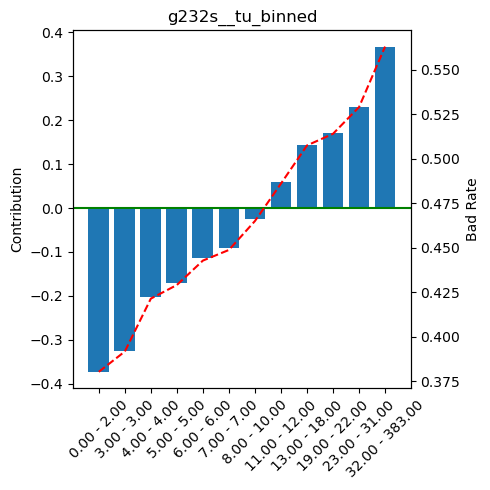

In [12]:
df_bins.sort_values(by='min', ascending=True, inplace=True)
# create label
df_bins['label'] = df_bins.apply(
    lambda x: f'{x["min"]:0.2f} - {x["max"]:0.2f}',
    axis=1,
)

# plot
fig, ax = plt.subplots(figsize=(5, 5))

# x and y
x = df_bins['label']
y = df_bins['contribution']
z = df_bins['target']
# plot
ax.set_title('g232s__tu_binned')
ax.set_ylabel('Contribution')
ax.bar(x, y)
ax.set_xticklabels(x, rotation=45)
# horizontal line at 0
ax.axhline(0, color='green')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Bad Rate')
ax2.plot(x, z, color='red', linestyle='--')

# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_g232s.png'
str_local_path = f'./output/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

## Now do this for ENG-wtd-avg

In [13]:
df = df[df['ENG-bk'] == 0]
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,NaN,2021-07-01,2,0.000048,train,1,0,0
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,1,0.0,2021-07-01,4,0.000096,train,1,0,0
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,1,0.0,2021-07-01,5,0.000120,train,1,0,0
8,5709029,2021-07-27 09:42:40.7808217,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Missouri,Franchise,Missouri,False,...,0,0,NaN,2021-07-01,9,0.000216,train,1,0,0
10,5709609,2021-07-27 09:47:57.8551698,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Indiana,Franchise,Indiana,True,...,1,0,0.0,2021-07-01,10,0.000240,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41687,6452209,2022-11-30 23:27:45+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,0,0,Alabama,Franchise,Alabama,False,...,0,0,0.0,2022-11-01,41688,0.999760,holdout,0,0,1
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,1,0.0,2022-11-01,41694,0.999904,holdout,0,0,1
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0,0.0,2022-11-01,41695,0.999928,holdout,0,0,1
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,0,NaN,2022-11-01,41696,0.999952,holdout,0,0,1


In [14]:
list_cols = [
    'g232s__tu',
    'ENG-wtd_avg',
#     'ENG-bk',
            ]

# list_cols.append(str_target)
df_tmp = df[list_cols]

# fill na 0 for wtd avg
df_tmp['ENG-wtd_avg'] = df_tmp['ENG-wtd_avg'].fillna(0)

# fill na with max for g232s__tu fill with 383
df_tmp['g232s__tu'] = df_tmp['g232s__tu'].fillna(383)

# show
df_tmp

/tmp/ipykernel_14365/2958980101.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['ENG-wtd_avg'] = df_tmp['ENG-wtd_avg'].fillna(0)
/tmp/ipykernel_14365/2958980101.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['g232s__tu'] = df_tmp['g232s__tu'].fillna(383)


,g232s__tu,ENG-wtd_avg
1,3.0,0.000000
3,31.0,1.000000
4,1.0,1.000000
8,1.0,0.000000
10,34.0,1.000000
...,...,...
41687,15.0,0.564103
41693,31.0,0.133005
41694,30.0,0.384615
41695,10.0,0.000000


In [15]:
dict_bins, list_cols_scorecard, X = bin_features(
    list_cols=list_cols,
    X=df_tmp,
    y=df[str_target],
    dict_monotone_constraints=dict_monotone_constraints,
)
# pickle dict_bins
str_filename = 'dict_bins.pkl'
str_local_path = f'./output/{str_filename}'
pickle.dump(dict_bins, open(str_local_path, 'wb'))

  0%|          | 0/2 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/

100%|██████████| 2/2 [00:00<00:00, 11.21it/s]


In [16]:
# import
str_filename = './output/dict_bins.pkl'
str_local_path = f'{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# transform
for key, val in tqdm(dict_bins.items()):
    try:
        df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])
    except KeyError:
        pass

  0%|          | 0/2 [00:00<?, ?it/s]/tmp/ipykernel_14365/2286728030.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp[f'{key}_binned'] = val.transform(df_tmp[key])
100%|██████████| 2/2 [00:00<00:00, 399.31it/s]


In [17]:
# get binned named
list_cols_binned = [col for col in list(df_tmp.columns) if 'binned' in col]

# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_binned):
    int_n_unique = df_tmp[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
for a, col in enumerate(list_col_no_var):
    print(f'{a+1} - {col}')
# rm
list_cols_binned = [col for col in list_cols_binned if col not in list_col_no_var]
print(f'There are {len(list_cols_binned)} features with good variance')

100%|██████████| 2/2 [00:00<00:00, 1855.48it/s]

There are 0 features with no variance after binning
There are 2 features with good variance


### fit simple logistic regression for wtd avg

In [18]:
cls_model_inference = LogisticRegression(
    fit_intercept=True
)

cls_model_inference.fit(
    df_tmp[['ENG-wtd_avg']],
    df[str_target],
)

flt_coef = cls_model_inference.coef_[0][0]

flt_coef

-0.25625144615162027

In [20]:
# show bins
df_tmp = df_tmp.copy()
df_tmp['target'] = df[str_target]
list_df = []
for col in tqdm(list_cols_binned):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)
    
    #print(f'{a+1} - {str_col_original}')
    #print(df_grouped)
    #print()

# make df
df_bins = pd.concat(list_df)

# make coef column
df_bins['coef'] = flt_coef

# make contribution column
df_bins['contribution'] = df_bins['coef'] * df_bins['bin']

# show df_bins
df_bins

100%|██████████| 2/2 [00:00<00:00, 111.99it/s]


,feature,bin,min,max,count,prop,target,bin_label,coef,contribution
10,g232s__tu_binned,0.287849,0.000000,2.000000,2171,0.064021,0.416398,1,-0.256251,-0.073762
9,g232s__tu_binned,0.267641,3.000000,3.000000,1792,0.052844,0.421317,2,-0.256251,-0.068583
8,g232s__tu_binned,0.168584,4.000000,4.000000,2235,0.065908,0.445638,3,-0.256251,-0.043200
7,g232s__tu_binned,0.123405,5.000000,5.000000,2154,0.063519,0.456825,4,-0.256251,-0.031623
6,g232s__tu_binned,0.107388,6.000000,6.000000,2296,0.067707,0.460801,5,-0.256251,-0.027518
5,g232s__tu_binned,0.058800,7.000000,7.000000,2066,0.060924,0.472894,6,-0.256251,-0.015068
4,g232s__tu_binned,0.015231,8.000000,11.000000,7053,0.207986,0.483766,7,-0.256251,-0.003903
3,g232s__tu_binned,-0.100686,12.000000,13.000000,2748,0.081036,0.512737,8,-0.256251,0.025801
2,g232s__tu_binned,-0.113976,14.000000,19.000000,5325,0.157029,0.516056,9,-0.256251,0.029207
1,g232s__tu_binned,-0.162223,20.000000,25.000000,2812,0.082923,0.528094,10,-0.256251,0.041570


In [21]:
# sub set to only the g232s__tu
df_bins = df_bins[df_bins['feature'] == 'ENG-wtd_avg_binned']

In [22]:
df_bins

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution
0,ENG-wtd_avg_binned,-0.104089,0.000000,0.549977,18437,0.543688,0.513587,1,-0.256251,0.026673
1,ENG-wtd_avg_binned,-0.053219,0.550000,0.600000,573,0.016897,0.500873,2,-0.256251,0.013637
2,ENG-wtd_avg_binned,-0.027086,0.600518,0.649823,530,0.015629,0.494340,3,-0.256251,0.006941
3,ENG-wtd_avg_binned,-0.021835,0.650000,0.749482,1219,0.035947,0.493027,4,-0.256251,0.005595
4,ENG-wtd_avg_binned,0.032362,0.750000,0.849802,1487,0.043850,0.479489,5,-0.256251,-0.008293
5,ENG-wtd_avg_binned,0.150720,0.850139,0.950000,1822,0.053729,0.450055,6,-0.256251,-0.038622
6,ENG-wtd_avg_binned,0.170398,0.950067,1.000000,9843,0.290260,0.445189,7,-0.256251,-0.043665


#### Plot it

/tmp/ipykernel_14365/2962731540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bins.sort_values(by='min', ascending=True, inplace=True)
/tmp/ipykernel_14365/2962731540.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bins['label'] = df_bins.apply(
/tmp/ipykernel_14365/2962731540.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)


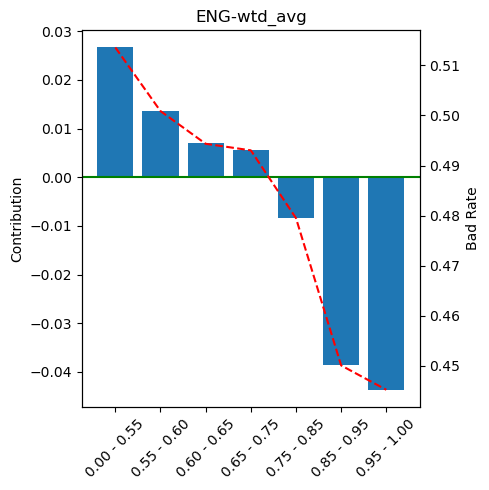

In [23]:
df_bins.sort_values(by='min', ascending=True, inplace=True)
# create label
df_bins['label'] = df_bins.apply(
    lambda x: f'{x["min"]:0.2f} - {x["max"]:0.2f}',
    axis=1,
)

# plot
fig, ax = plt.subplots(figsize=(5, 5))
if 

# x and y
x = df_bins['label']
y = df_bins['contribution']
z = df_bins['target']
# plot
ax.set_title('ENG-wtd_avg')
ax.set_ylabel('Contribution')
ax.bar(x, y)
ax.set_xticklabels(x, rotation=45)
# horizontal line at 0
ax.axhline(0, color='green')
# second y
ax2 = ax.twinx()
ax2.set_ylabel('Bad Rate')
ax2.plot(x, z, color='red', linestyle='--')

# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_wtd_avg.png'
str_local_path = f'./output/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()